# Neuro-Symbolic PPM — BPIC_2020_DomesticDeclarations (T-LEAF · noise × data-scarcity)

**The question.** Following the PPM pipeline `event log → prefix log → encoding → learning → validation → runtime prediction`, does **clean symbolic temporal knowledge** keep a neural next-activity model accurate and process-conformant when its training data is both **scarce** and **noisy**?

We mine the symbolic layer — an empirical **directly-follows DFA** and **LTLf precedence** rules `a precedes b ≡ (¬b U a) ∨ G(¬b)` — **once, from the full clean training set**, and hold it fixed. Then we vary only the *neural* training data along two crossed axes:

- **data scarcity** — nested training subsets `1 ⊃ 1/2 ⊃ 1/4 ⊃ 1/8` of the cases;
- **label noise** — corrupt 0 / 10 / 25 / 40 % of the (subset's) training targets with a random DFA activity.

Validation and test stay clean and fixed, so every grid cell is comparable.

Four variants × two architectures (GRU, LSTM):
- **baseline** — cross-entropy only;
- **baseline+mask** — baseline weights, DFA-forbidden classes removed at inference (output refinement);
- **checker** — trained with the differentiable forbidden-mass logic loss (T-LEAF *checker*);
- **embedder** — trained with the T-LEAF embedding logic loss `‖q(A) − q(w_pred)‖²` (skill `TLEAF`).

> Background skills: `ppm-skills` (PPM pipeline) · `TLEAF` (LTLf, DFA embedding, logic loss) · `dtl-temp-logic-skill` (differentiable temporal logic).
>
> **Design note.** The symbolic layer (vocabulary, DFA, constraints, embedder) is built from the *full clean* training set and reused across the whole grid — this is the "clean knowledge vs dirty/scarce data" hypothesis, and keeps the test set and output space fixed for comparability.

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

import pandas as pd
import torch
from IPython.display import Image, display

# Make `src.nspm` importable from anywhere under the repository.
ROOT = Path.cwd()
while not (ROOT / "src" / "nspm").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nspm.config import ExperimentConfig, ProjectPaths
from src.nspm.data.loader import read_xes
from src.nspm.data.preparation import ActivityVocabulary, TraceSplits, TraceUtils
from src.nspm.pipeline.analysis import build_analysis_tables, summarise
from src.nspm.process.automaton import ProcessDFA
from src.nspm.process.graph_encoding import FeatureSpace
from src.nspm.process.ltl_constraints import mine_precedence_constraints
from src.nspm.learning.logic import EmbeddingLogicLoss, build_allowed_mask
from src.nspm.learning.embedder import HierarchicalEmbedder
from src.nspm.learning.embedder_training import EmbedderConfig, train_embedder
from src.nspm.learning.training import resolve_device
from src.nspm.pipeline.benchmark import run_corruption_grid
from src.nspm.visualization import plots

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
device = resolve_device("auto")
print("device:", device)

device: cuda


## 1. Configuration

The **only** difference between the three dataset notebooks is `DATASET_NAME`.
`FORCE_RERUN=False` reuses the cached grid in `runs/benchmark_corruption.csv`, so
re-opening the notebook is cheap; set it to `True` to recompute from scratch.

In [2]:
# --- experiment parameters (only DATASET_NAME differs across the three notebooks) ---
DATASET_NAME    = "BPIC_2020_DomesticDeclarations"

MODELS          = ["gru", "lstm"]                 # transformer wired but off for now
VARIANTS        = ["baseline", "baseline_mask", "checker", "embedder"]
NOISE_LEVELS    = [0.0, 0.1, 0.25, 0.4]           # fraction of training targets corrupted
TRAIN_FRACTIONS = [1.0, 0.5, 0.25, 0.125]         # nested subsets of training cases
EPOCHS          = 30                              # long runs; early stopping cuts most short
EMBEDDER_EPOCHS = 5
LOGIC_WEIGHT    = 0.5
SEED            = 42
DROP_UNSEEN     = True                            # drop held-out cases with unseen activities
MAX_CASES       = None                            # cap cases for a quick smoke run
FORCE_RERUN     = False                           # recompute even if cached results exist

In [3]:
config = ExperimentConfig(seed=SEED)
paths = ProjectPaths.from_root(ROOT, DATASET_NAME)
DATA_PATH = paths.dataset
OUTPUT_DIR = ROOT / "runs" / DATASET_NAME / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = ROOT / "runs" / "benchmark_corruption.csv"
print("dataset :", DATASET_NAME)
print("log file:", DATA_PATH.name)

dataset : BPIC_2020_DomesticDeclarations
log file: DomesticDeclarations.xes


## 2. The event log — exploration

Load the XES log once and explore it: a compact summary, the activity frequency,
case-duration distribution and the most common variants. (We pass
`outcome_markers={}` so the case table carries no dataset-specific outcome flags
— those are a Sepsis-only preset.)

In [4]:
events = read_xes(DATA_PATH, max_cases=MAX_CASES)
tables = build_analysis_tables(events)
summary = summarise(tables, DATA_PATH)
print(json.dumps({k: summary[k] for k in ["cases", "events", "activities", "variants"]}, indent=2))
display(tables.activities.head(10))

C:\Users\Matteo\miniconda3\envs\tleaf\lib\site-packages\pm4py\utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


{
  "cases": 10500,
  "events": 56437,
  "activities": 17,
  "variants": 99
}


,concept:name,count
0,Declaration SUBMITTED by EMPLOYEE,11531
1,Declaration FINAL_APPROVED by SUPERVISOR,10131
2,Payment Handled,10044
3,Request Payment,10040
4,Declaration APPROVED by ADMINISTRATION,8202
5,Declaration APPROVED by BUDGET OWNER,2820
6,Declaration REJECTED by EMPLOYEE,1365
7,Declaration REJECTED by ADMINISTRATION,952
8,Declaration APPROVED by PRE_APPROVER,685
9,Declaration REJECTED by SUPERVISOR,293


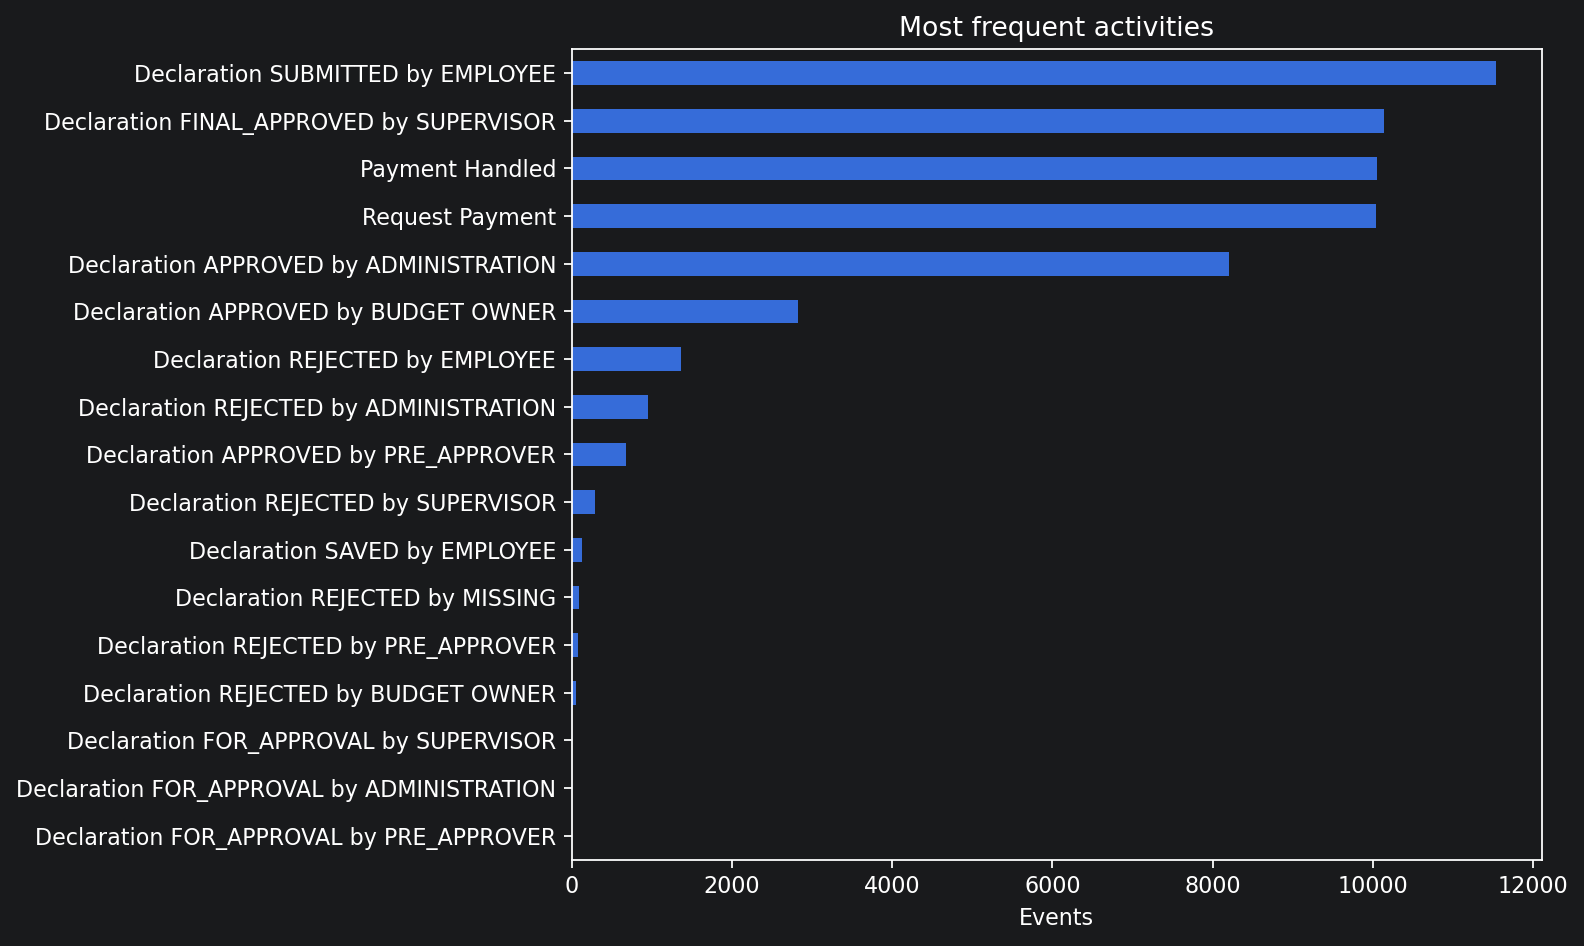

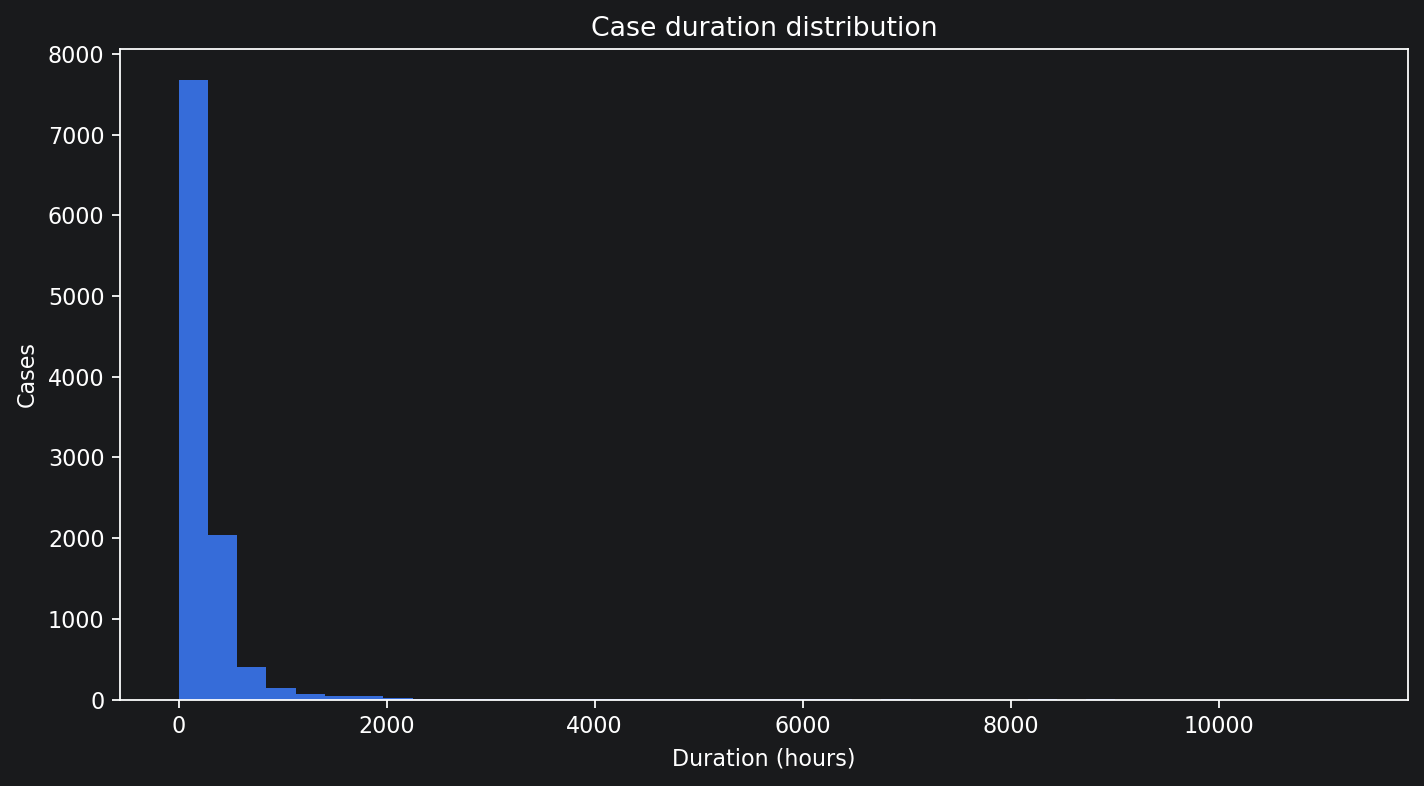

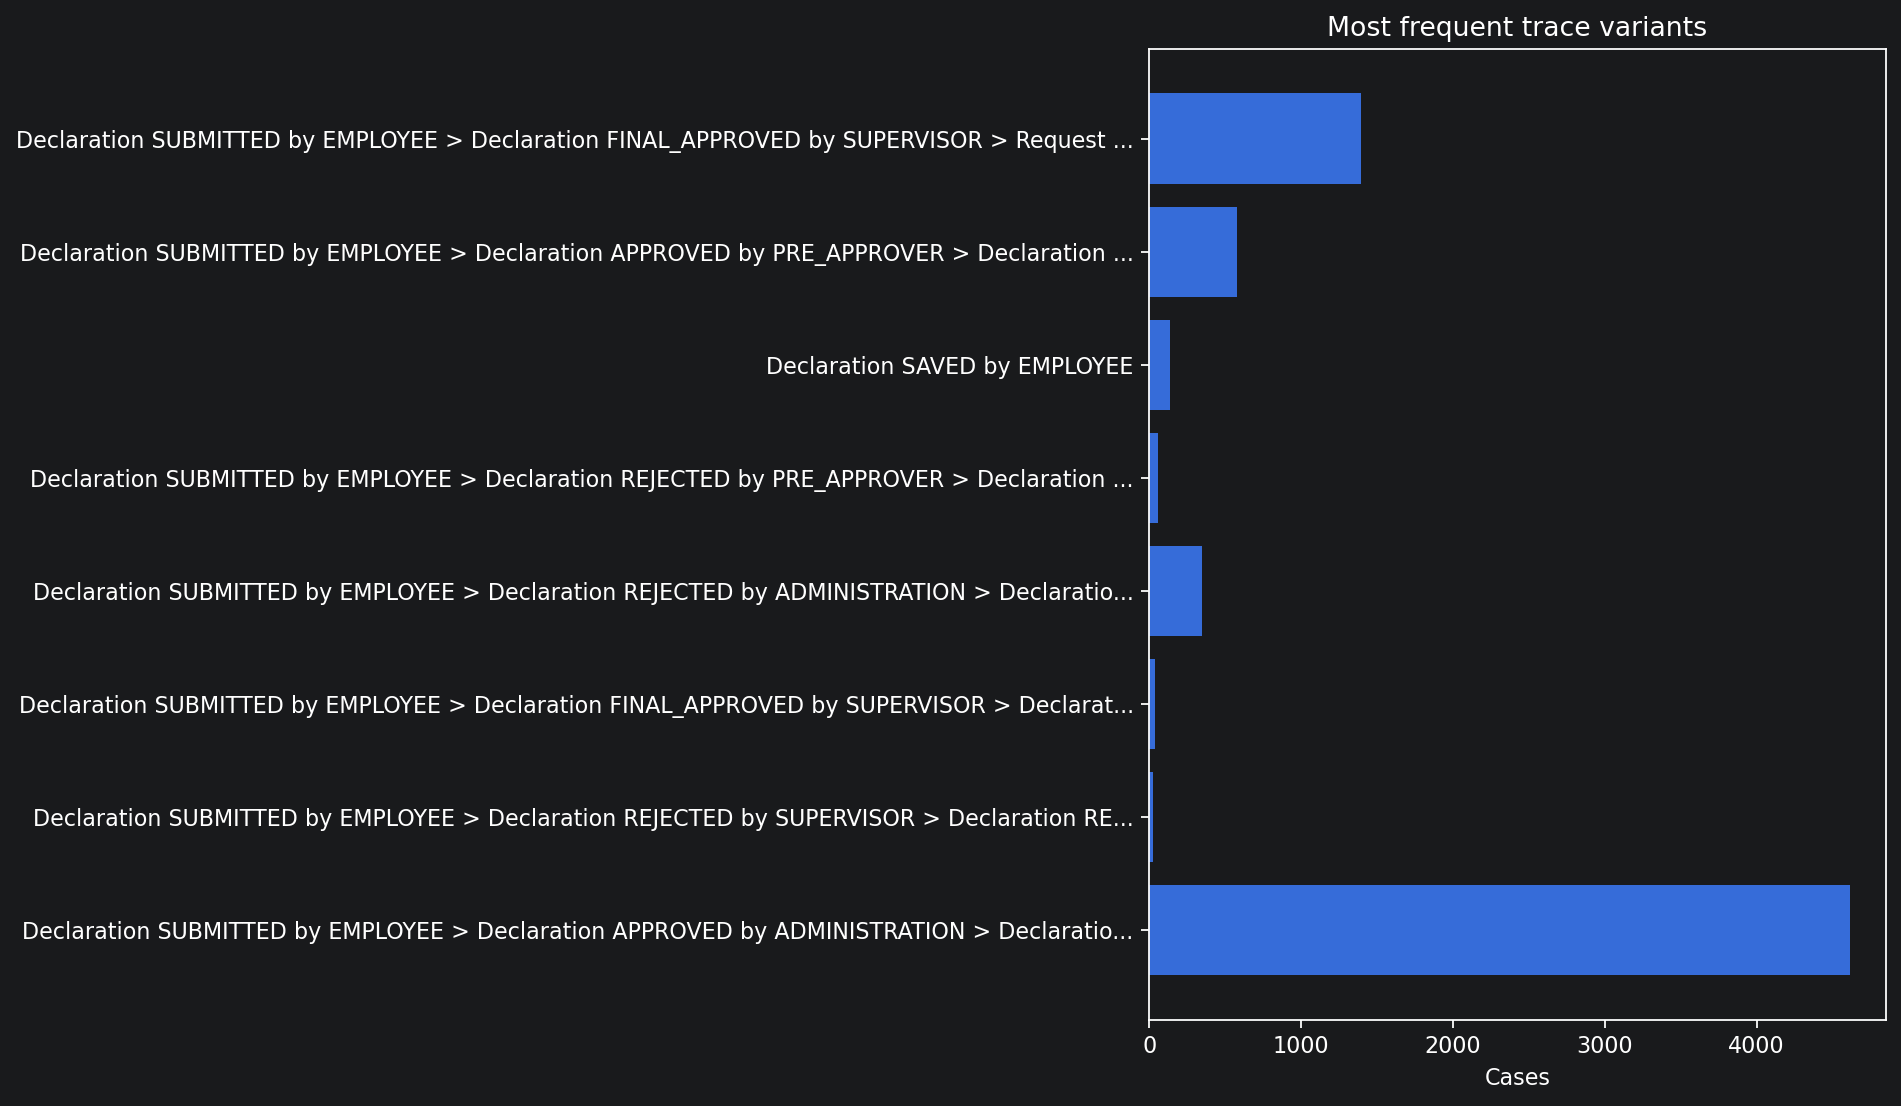

In [5]:
plots.plot_activity_frequency(events, OUTPUT_DIR / "activity_frequency.png")
plots.plot_case_durations(tables.cases, OUTPUT_DIR / "case_durations.png")
plots.plot_variants(tables.variants, OUTPUT_DIR / "top_variants.png")
for name in ["activity_frequency", "case_durations", "top_variants"]:
    display(Image(filename=str(OUTPUT_DIR / f"{name}.png")))

## 3. From log to a supervised learning problem

We **split by case id** (no case's prefixes leak across train/val/test), build the
**activity vocabulary**, and generate one prefix → next-activity example per
event.

In [6]:
traces = TraceUtils.extract_traces(events)
splits = TraceSplits.from_traces(
    traces,
    validation_fraction=config.data.validation_fraction,
    test_fraction=config.data.test_fraction,
    seed=config.seed,
)
vocab = ActivityVocabulary.from_traces(splits.train.values())
n_prefix = sum(len(t) for t in splits.train.values())
print(f"cases  train / val / test : {len(splits.train)} / {len(splits.validation)} / {len(splits.test)}")
print(f"activities (vocabulary)   : {len(vocab.activities)}")
print(f"training prefix examples  : {n_prefix}")

cases  train / val / test : 7350 / 1575 / 1575
activities (vocabulary)   : 16
training prefix examples  : 39432


## 4. The symbolic knowledge: a DFA and LTLf precedence rules — from the **clean** full training set

Two symbolic objects, mined from clean training traces only and held fixed:

- the empirical **directly-follows DFA** — it powers the **checker** loss and the
  inference-time decoding mask;
- mined **LTLf precedence** rules `a precedes b ≡ (¬b U a) ∨ G(¬b)`, each a tiny
  3-state DFA — the knowledge the **embedder** learns.

In [7]:
automaton = ProcessDFA.from_traces(splits.train.values())
mask = build_allowed_mask(automaton, vocab)
constraints = mine_precedence_constraints(
    splits.train.values(),
    min_support=max(3, len(splits.train) // 10),
    min_confidence=0.95,
    max_constraints=15,
)
print(f"DFA: {len(automaton.states)} states, {automaton.transition_count} transitions")
print(f"test transition coverage: {automaton.transition_coverage(splits.test.values()):.3f}")
print(f"mined LTLf precedence constraints: {len(constraints)}")
display(pd.DataFrame(
    [{"earlier": c.earlier, "later": c.later, "support": c.support,
      "confidence": round(c.confidence, 3), "LTLf": c.to_ltlf()} for c in constraints]
))

DFA: 18 states, 43 transitions
test transition coverage: 1.000
mined LTLf precedence constraints: 10


,earlier,later,support,confidence,LTLf
0,Declaration SUBMITTED by EMPLOYEE,Declaration FINAL_APPROVED by SUPERVISOR,7035,1.000,(!'Declaration FINAL_APPROVED by SUPERVISOR' U...
1,Declaration SUBMITTED by EMPLOYEE,Declaration APPROVED by ADMINISTRATION,5574,1.000,(!'Declaration APPROVED by ADMINISTRATION' U '...
2,Declaration APPROVED by ADMINISTRATION,Declaration APPROVED by BUDGET OWNER,1953,1.000,(!'Declaration APPROVED by BUDGET OWNER' U 'De...
3,Declaration SUBMITTED by EMPLOYEE,Declaration APPROVED by BUDGET OWNER,1953,1.000,(!'Declaration APPROVED by BUDGET OWNER' U 'De...
4,Declaration SUBMITTED by EMPLOYEE,Declaration REJECTED by EMPLOYEE,847,1.000,(!'Declaration REJECTED by EMPLOYEE' U 'Declar...
5,Declaration FINAL_APPROVED by SUPERVISOR,Payment Handled,7018,1.000,(!'Payment Handled' U 'Declaration FINAL_APPRO...
6,Declaration SUBMITTED by EMPLOYEE,Payment Handled,7018,1.000,(!'Payment Handled' U 'Declaration SUBMITTED b...
7,Declaration FINAL_APPROVED by SUPERVISOR,Request Payment,7014,1.000,(!'Request Payment' U 'Declaration FINAL_APPRO...
8,Declaration SUBMITTED by EMPLOYEE,Request Payment,7014,1.000,(!'Request Payment' U 'Declaration SUBMITTED b...
9,Request Payment,Payment Handled,7018,0.999,(!'Payment Handled' U 'Request Payment') | G(!...


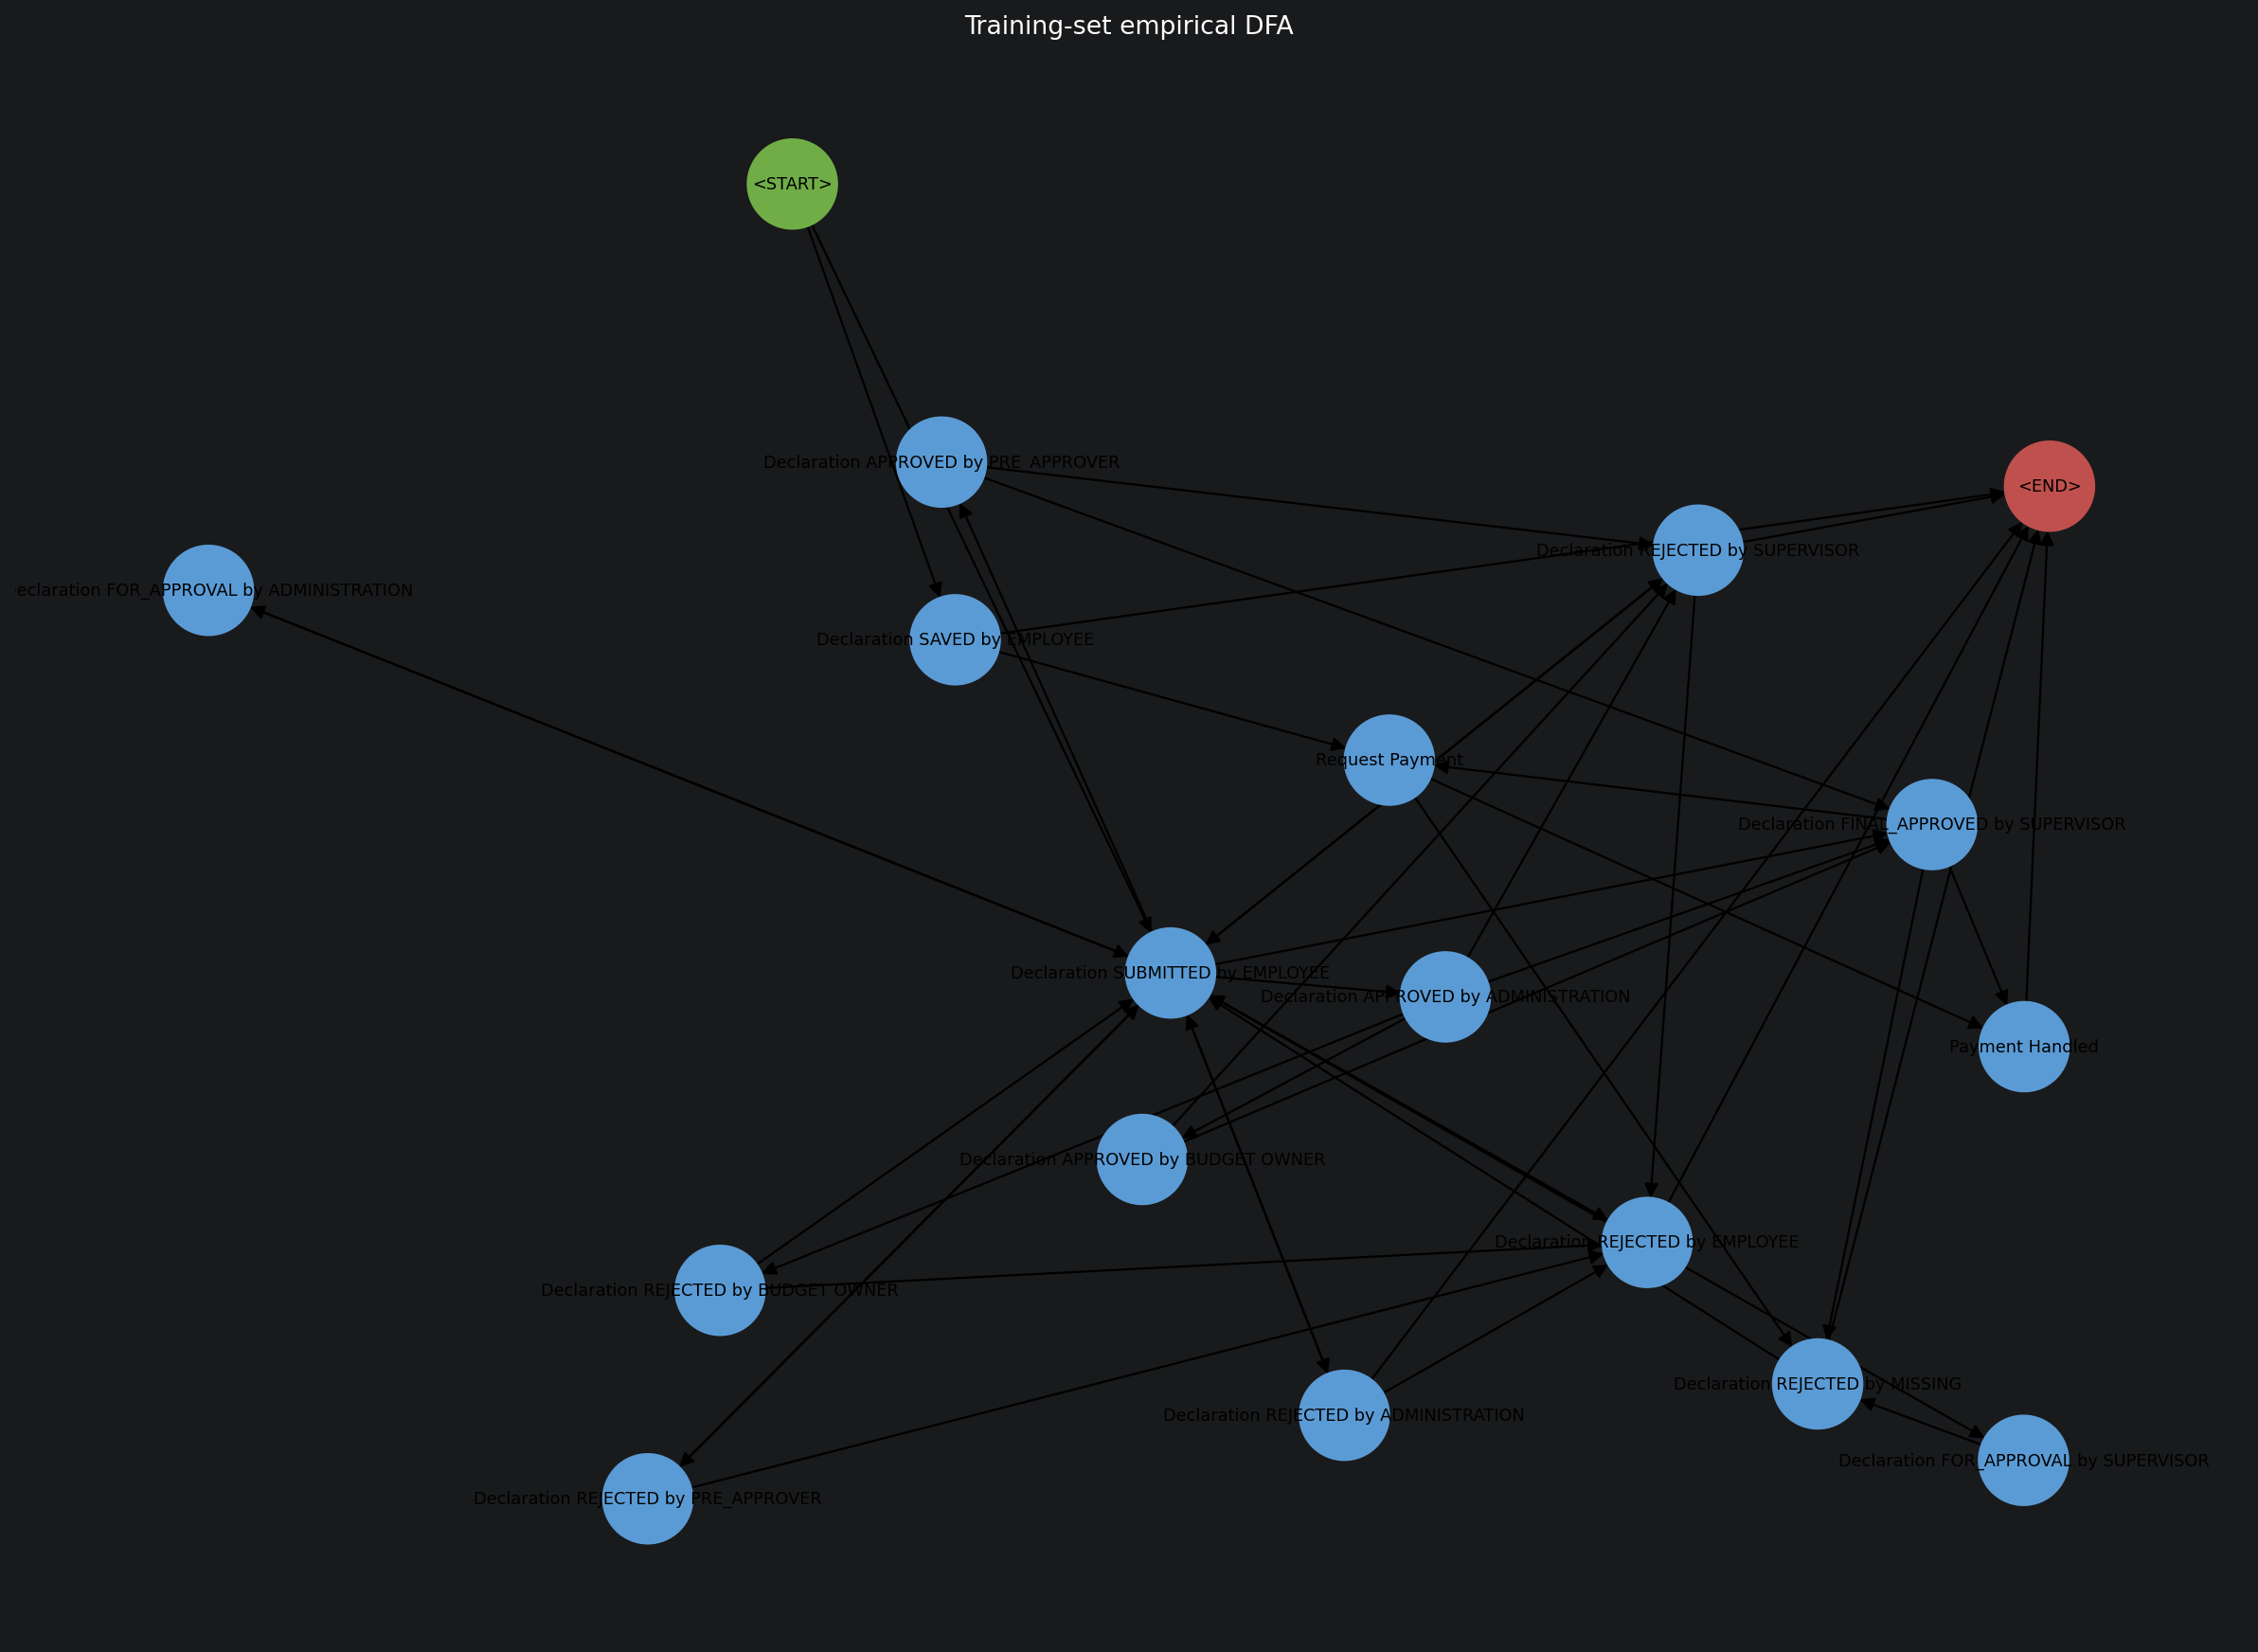

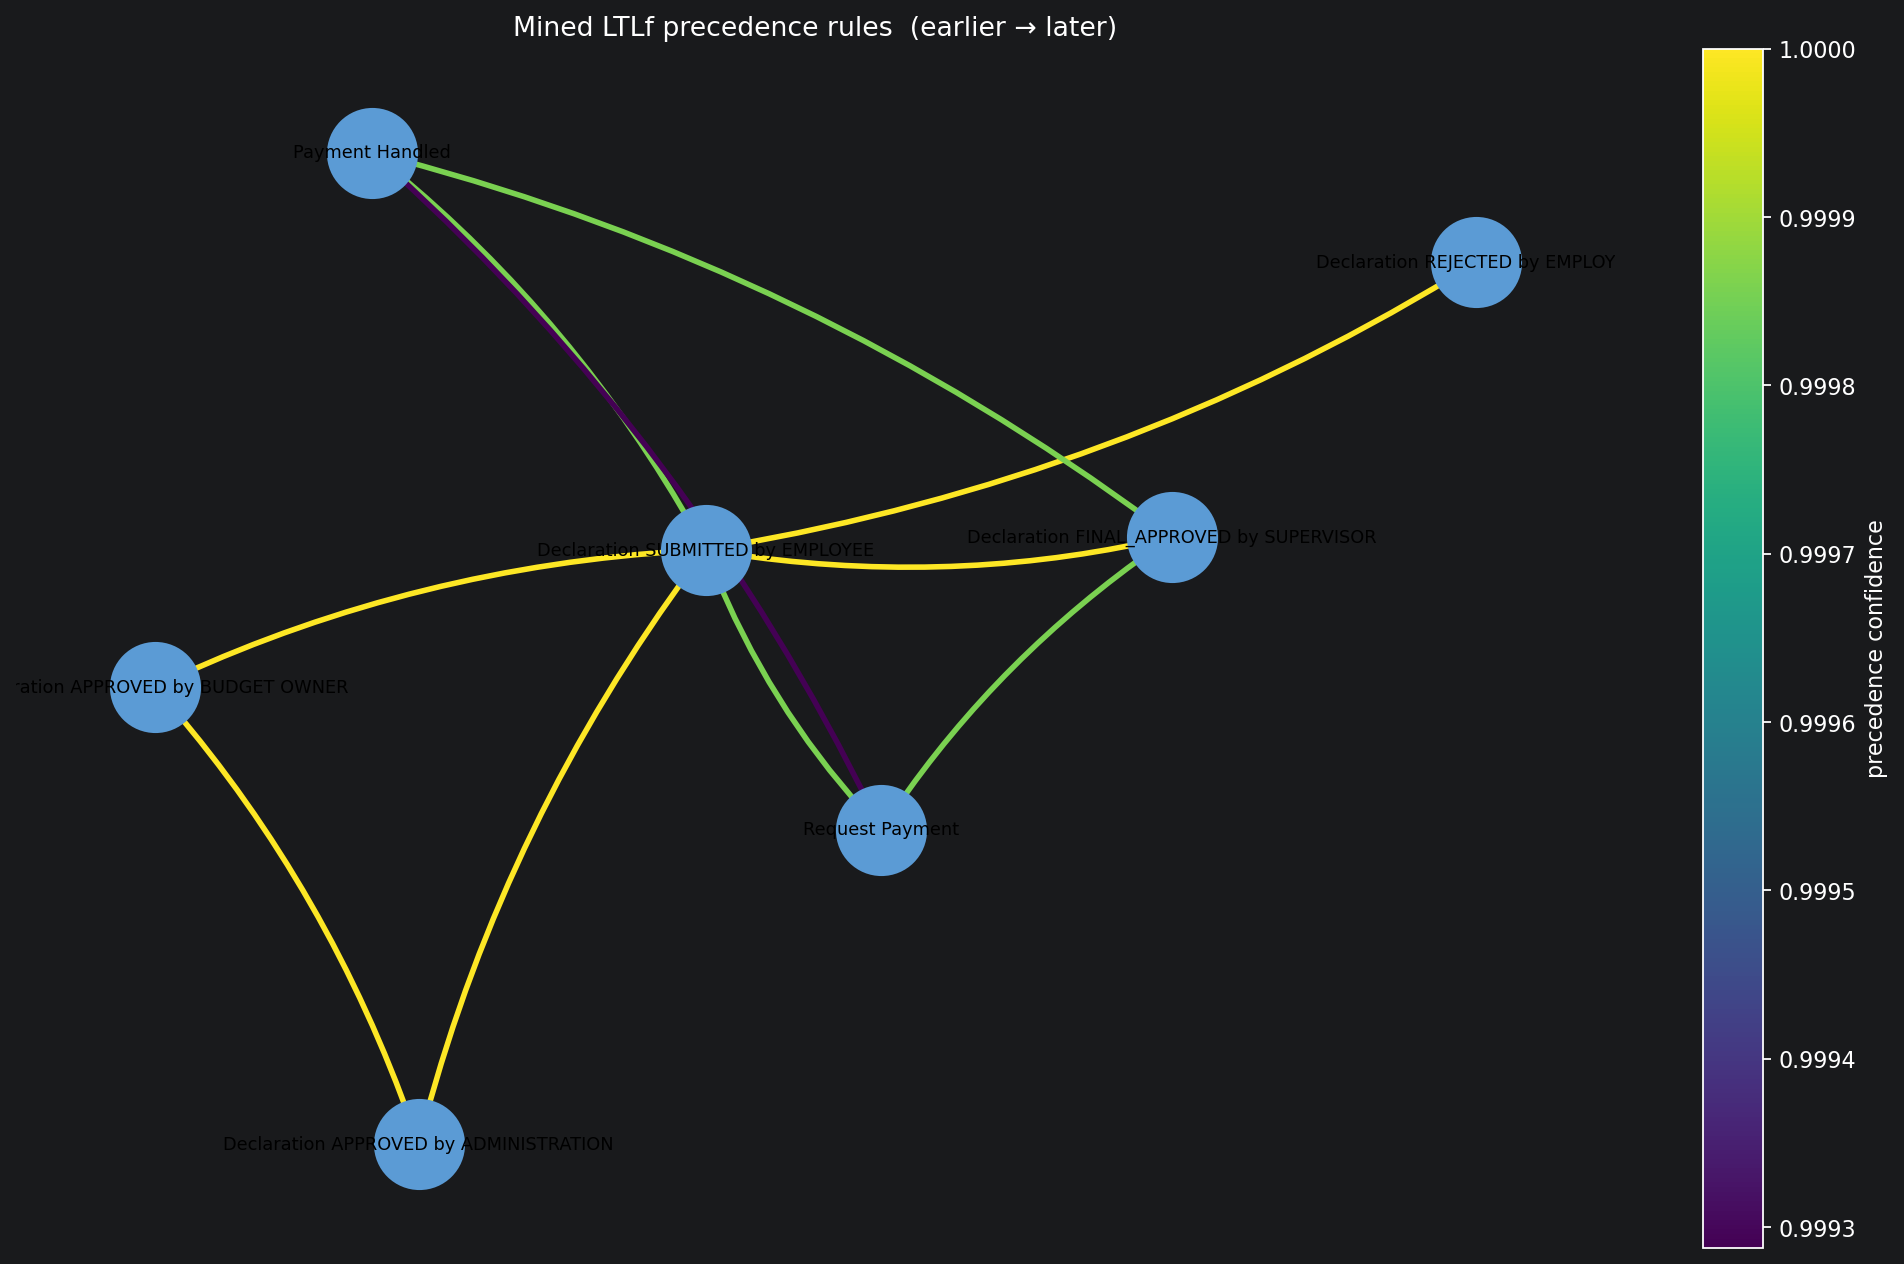

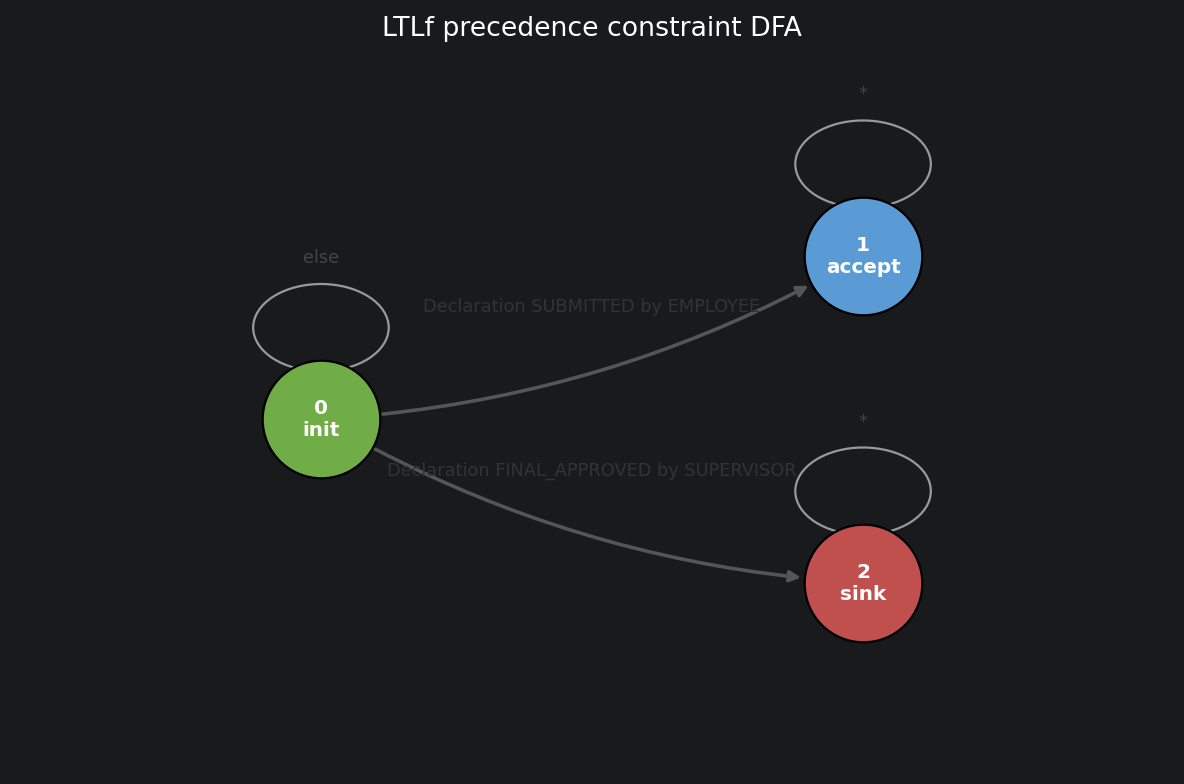

In [8]:
plots.plot_automaton(automaton, OUTPUT_DIR / "dfa.png")
display(Image(filename=str(OUTPUT_DIR / "dfa.png")))
if constraints:
    plots.plot_precedence_constraints(constraints, OUTPUT_DIR / "constraints.png")
    plots.plot_constraint_dfa(constraints[0].to_dfa(), OUTPUT_DIR / "constraint_dfa.png")
    display(Image(filename=str(OUTPUT_DIR / "constraints.png")))
    display(Image(filename=str(OUTPUT_DIR / "constraint_dfa.png")))

## 5. Embedding the knowledge (the T-LEAF embedder)

T-LEAF embeds each constraint DFA and each predicted trace into a shared vector
space with a hierarchical GNN `q = (qe, qm)`, trained by a **triplet hinge loss**
that pulls a rule toward its satisfying traces and away from violating ones
(skill `TLEAF`). The frozen embedder then defines the logic loss
`‖q(A) − q(w_pred)‖²` used by the *embedder* variant. We train it here for
illustration; the grid trains an identical one internally.

embedder epoch 01 loss=4.9948 acc=0.567
embedder epoch 02 loss=4.9982 acc=0.467
embedder epoch 03 loss=4.9828 acc=0.550
embedder epoch 04 loss=4.7795 acc=0.575
embedder epoch 05 loss=5.0131 acc=0.558


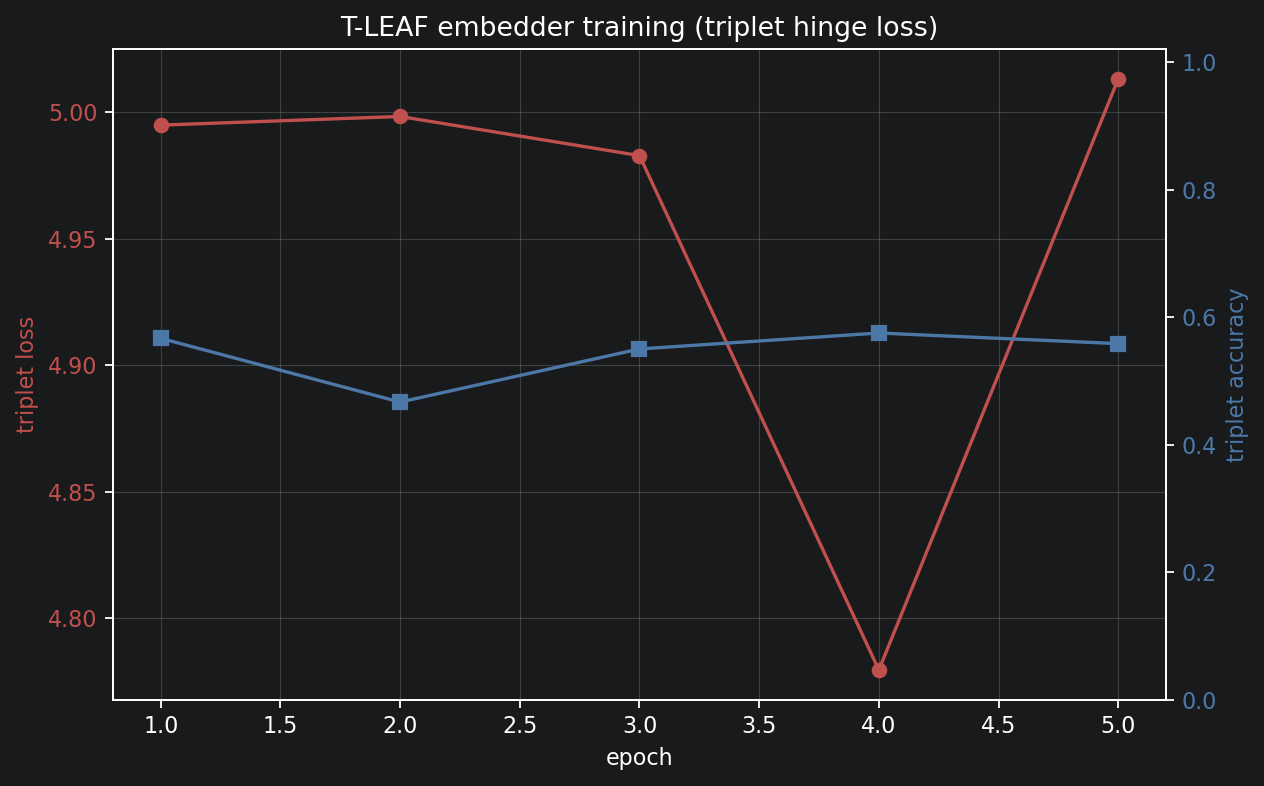

final triplet ranking accuracy: 0.558


In [9]:
if constraints:
    space = FeatureSpace.create(vocab.activities, prop_dim=50, node_dim=100,
                                seed=config.seed, device=device)
    embedder = HierarchicalEmbedder(aggregation="random_walk", normalize=False,
                                    meta_layers=2).to(device)
    emb_history = train_embedder(
        embedder, space, constraints, vocab.activities,
        EmbedderConfig(epochs=EMBEDDER_EPOCHS, triplets_per_constraint=12,
                       margin=5.0, learning_rate=2e-3, seed=config.seed),
        device=device, verbose=True,
    )
    plots.plot_embedder_training(emb_history, OUTPUT_DIR / "embedder_training.png")
    display(Image(filename=str(OUTPUT_DIR / "embedder_training.png")))
    print(f"final triplet ranking accuracy: {emb_history['triplet_accuracy'].iloc[-1]:.3f}")
else:
    print("no constraints mined -> embedder branch unavailable")

## 6. The grid: label noise × training-set size

`run_corruption_grid` does the heavy lifting. The symbolic layer above is rebuilt
once internally from the full clean training set, then for every
`(model, train_fraction, noise)` cell it subsamples the training cases, corrupts
that fraction of training targets, trains the variants and evaluates them on the
clean test set — one tidy row per evaluated model. Cached results are reused
unless `FORCE_RERUN=True`.

In [10]:
RESULTS_CSV.parent.mkdir(parents=True, exist_ok=True)
cached = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else None
compatible = cached is not None and "train_fraction" in cached.columns
have = compatible and (cached["dataset"] == DATASET_NAME).any()

if FORCE_RERUN or not have:
    grid = run_corruption_grid(
        DATA_PATH, dataset_name=DATASET_NAME,
        model_kinds=tuple(MODELS), noise_levels=tuple(NOISE_LEVELS),
        train_fractions=tuple(TRAIN_FRACTIONS), variants=tuple(VARIANTS),
        epochs=EPOCHS, embedder_epochs=EMBEDDER_EPOCHS, logic_weight=LOGIC_WEIGHT,
        seed=SEED, drop_unseen=DROP_UNSEEN, max_cases=MAX_CASES, verbose=True,
    )
    others = cached[cached["dataset"] != DATASET_NAME] if compatible else None
    combined = grid if others is None else pd.concat([others, grid], ignore_index=True)
    combined.to_csv(RESULTS_CSV, index=False)
else:
    grid = cached[cached["dataset"] == DATASET_NAME].reset_index(drop=True)
    print(f"loaded cached results for {DATASET_NAME}")

METRICS = ["accuracy", "macro_f1", "macro_precision", "macro_recall", "top_k_accuracy",
           "violation_rate", "forbidden_mass", "precedence_violation_rate"]
display(grid[["architecture", "variant", "train_fraction", "noise_level"] + METRICS]
        .sort_values(["architecture", "variant", "train_fraction", "noise_level"])
        .round(4).reset_index(drop=True))

[BPIC_2020_DomesticDeclarations] dropped 1 validation / 0 test cases with unseen activities (1 activities)
embedder epoch 01 loss=4.9991 acc=0.558
embedder epoch 02 loss=4.9985 acc=0.458
embedder epoch 03 loss=4.9840 acc=0.592
embedder epoch 04 loss=4.8824 acc=0.558
embedder epoch 05 loss=5.0024 acc=0.508
[BPIC_2020_DomesticDeclarations] gru frac=1 noise=0.00 (7350 cases, 0/39432 corrupted)
[BPIC_2020_DomesticDeclarations] gru frac=1 noise=0.10 (7350 cases, 3943/39432 corrupted)
[BPIC_2020_DomesticDeclarations] gru frac=1 noise=0.25 (7350 cases, 9858/39432 corrupted)
[BPIC_2020_DomesticDeclarations] gru frac=1 noise=0.40 (7350 cases, 15773/39432 corrupted)
[BPIC_2020_DomesticDeclarations] gru frac=0.5 noise=0.00 (3675 cases, 0/19769 corrupted)
[BPIC_2020_DomesticDeclarations] gru frac=0.5 noise=0.10 (3675 cases, 1977/19769 corrupted)
[BPIC_2020_DomesticDeclarations] gru frac=0.5 noise=0.25 (3675 cases, 4942/19769 corrupted)
[BPIC_2020_DomesticDeclarations] gru frac=0.5 noise=0.40 (3675

,architecture,variant,train_fraction,noise_level,accuracy,macro_f1,macro_precision,macro_recall,top_k_accuracy,violation_rate,forbidden_mass,precedence_violation_rate
0,gru,baseline,0.125,0.00,0.8865,0.4191,0.4487,0.4282,0.9844,0.0001,0.0025,0.0000
1,gru,baseline,0.125,0.10,0.8847,0.4010,0.3881,0.4179,0.9834,0.0000,0.0767,0.0000
2,gru,baseline,0.125,0.25,0.8836,0.4006,0.3877,0.4175,0.9805,0.0000,0.2017,0.0000
3,gru,baseline,0.125,0.40,0.8820,0.3990,0.3871,0.4150,0.9810,0.0016,0.3291,0.0009
4,gru,baseline,0.250,0.00,0.8865,0.4191,0.4487,0.4282,0.9849,0.0000,0.0020,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
123,lstm,embedder,0.500,0.40,0.5909,0.2988,0.3944,0.3494,0.9557,0.1714,0.4047,0.0000
124,lstm,embedder,1.000,0.00,0.8828,0.4004,0.3877,0.4172,0.9563,0.0008,0.1150,0.0000
125,lstm,embedder,1.000,0.10,0.7565,0.3625,0.3933,0.4159,0.9557,0.0000,0.1862,0.0000
126,lstm,embedder,1.000,0.25,0.8105,0.3840,0.3830,0.3949,0.9557,0.0255,0.3087,0.0000


## 7. Experiment A: the clean corner

The classic next-activity comparison is the clean, full-data corner of the grid
(`train_fraction = 1.0`, `noise = 0.0`). On a log whose directly-follows
structure the baseline already absorbs, logic typically barely moves single-step
accuracy — the value of the symbolic prior shows up as the data gets dirtier and
scarcer (§8).

In [11]:
clean = grid[(grid.train_fraction == 1.0) & (grid.noise_level == 0.0)]
display(clean.set_index(["architecture", "variant"])[
    ["accuracy", "macro_f1", "top_k_accuracy", "forbidden_mass", "precedence_violation_rate"]
].round(4))

accuracy  macro_f1  top_k_accuracy  forbidden_mass  precedence_violation_rate
architecture variant                                                                                     
gru          baseline         0.8869    0.4222          0.9853          0.0008                        0.0
             baseline_mask    0.8869    0.4222          0.9853          0.0000                        0.0
             checker          0.8869    0.4222          0.9853          0.0005                        0.0
             embedder         0.8622    0.4131          0.9719          0.1018                        0.0
lstm         baseline         0.8869    0.4222          0.9853          0.0011                        0.0
             baseline_mask    0.8869    0.4222          0.9853          0.0000                        0.0
             checker          0.8869    0.4222          0.9851          0.0007                        0.0
             embedder         0.8828    0.4004          0.9563          0.1150                        0.0

## 8. Results across regimes

Pivot tables (rows = architecture × variant) at full data, plus learning curves
for the first architecture. Read **accuracy** (does it survive?) against
**forbidden_mass** / **precedence_violation_rate** (does the clean symbolic prior
keep the model conformant?). `baseline+mask` is conformant by construction.

In [12]:
for metric in ["accuracy", "forbidden_mass", "precedence_violation_rate"]:
    print(f"\n### {metric}  (rows: architecture x variant | cols: noise) @ train_fraction=1.0")
    sub = grid[grid.train_fraction == 1.0]
    display(sub.pivot_table(index=["architecture", "variant"],
                            columns="noise_level", values=metric).round(4))


### accuracy  (rows: architecture x variant | cols: noise) @ train_fraction=1.0


noise_level                   0.00    0.10    0.25    0.40
architecture variant                                      
gru          baseline       0.8869  0.8841  0.8865  0.8848
             baseline_mask  0.8869  0.8841  0.8865  0.8848
             checker        0.8869  0.8841  0.8865  0.8849
             embedder       0.8622  0.6570  0.7231  0.6553
lstm         baseline       0.8869  0.8865  0.8866  0.8836
             baseline_mask  0.8869  0.8865  0.8866  0.8836
             checker        0.8869  0.8865  0.8860  0.8836
             embedder       0.8828  0.7565  0.8105  0.6016


### forbidden_mass  (rows: architecture x variant | cols: noise) @ train_fraction=1.0


noise_level                   0.00    0.10    0.25    0.40
architecture variant                                      
gru          baseline       0.0008  0.0686  0.1873  0.3134
             baseline_mask  0.0000  0.0000  0.0000  0.0000
             checker        0.0005  0.0462  0.1285  0.2258
             embedder       0.1018  0.2107  0.2931  0.3853
lstm         baseline       0.0011  0.0701  0.1927  0.3157
             baseline_mask  0.0000  0.0000  0.0000  0.0000
             checker        0.0007  0.0469  0.1338  0.2275
             embedder       0.1150  0.1862  0.3087  0.3923


### precedence_violation_rate  (rows: architecture x variant | cols: noise) @ train_fraction=1.0


noise_level                 0.00  0.10  0.25  0.40
architecture variant                              
gru          baseline        0.0   0.0   0.0   0.0
             baseline_mask   0.0   0.0   0.0   0.0
             checker         0.0   0.0   0.0   0.0
             embedder        0.0   0.0   0.0   0.0
lstm         baseline        0.0   0.0   0.0   0.0
             baseline_mask   0.0   0.0   0.0   0.0
             checker         0.0   0.0   0.0   0.0
             embedder        0.0   0.0   0.0   0.0

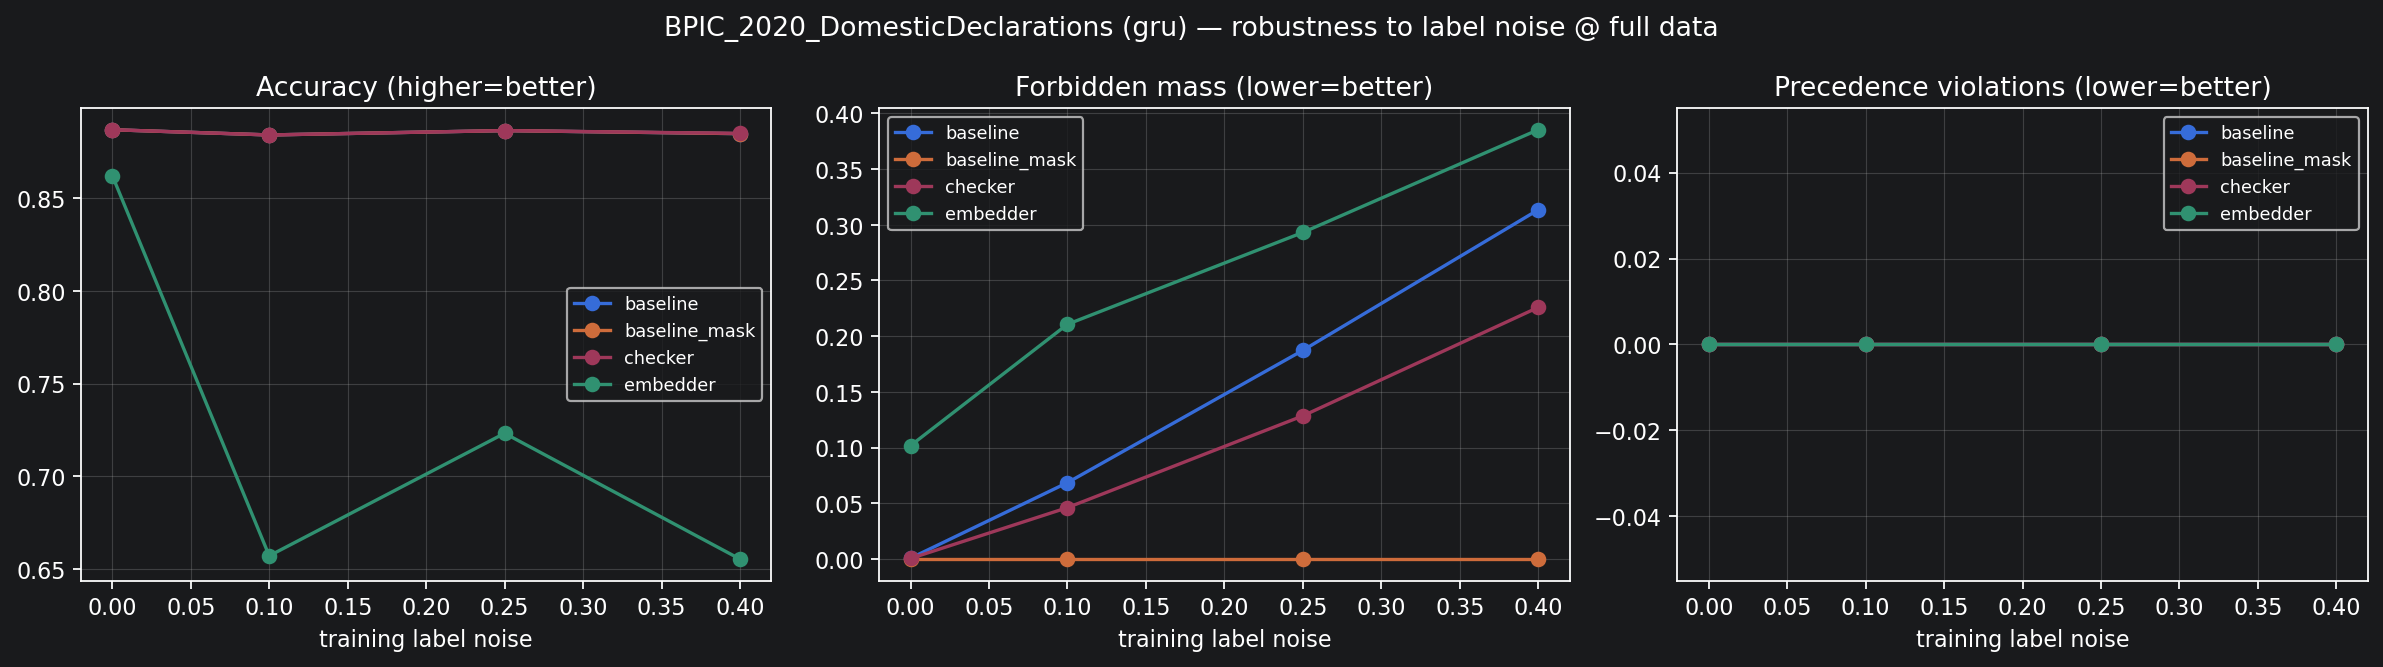

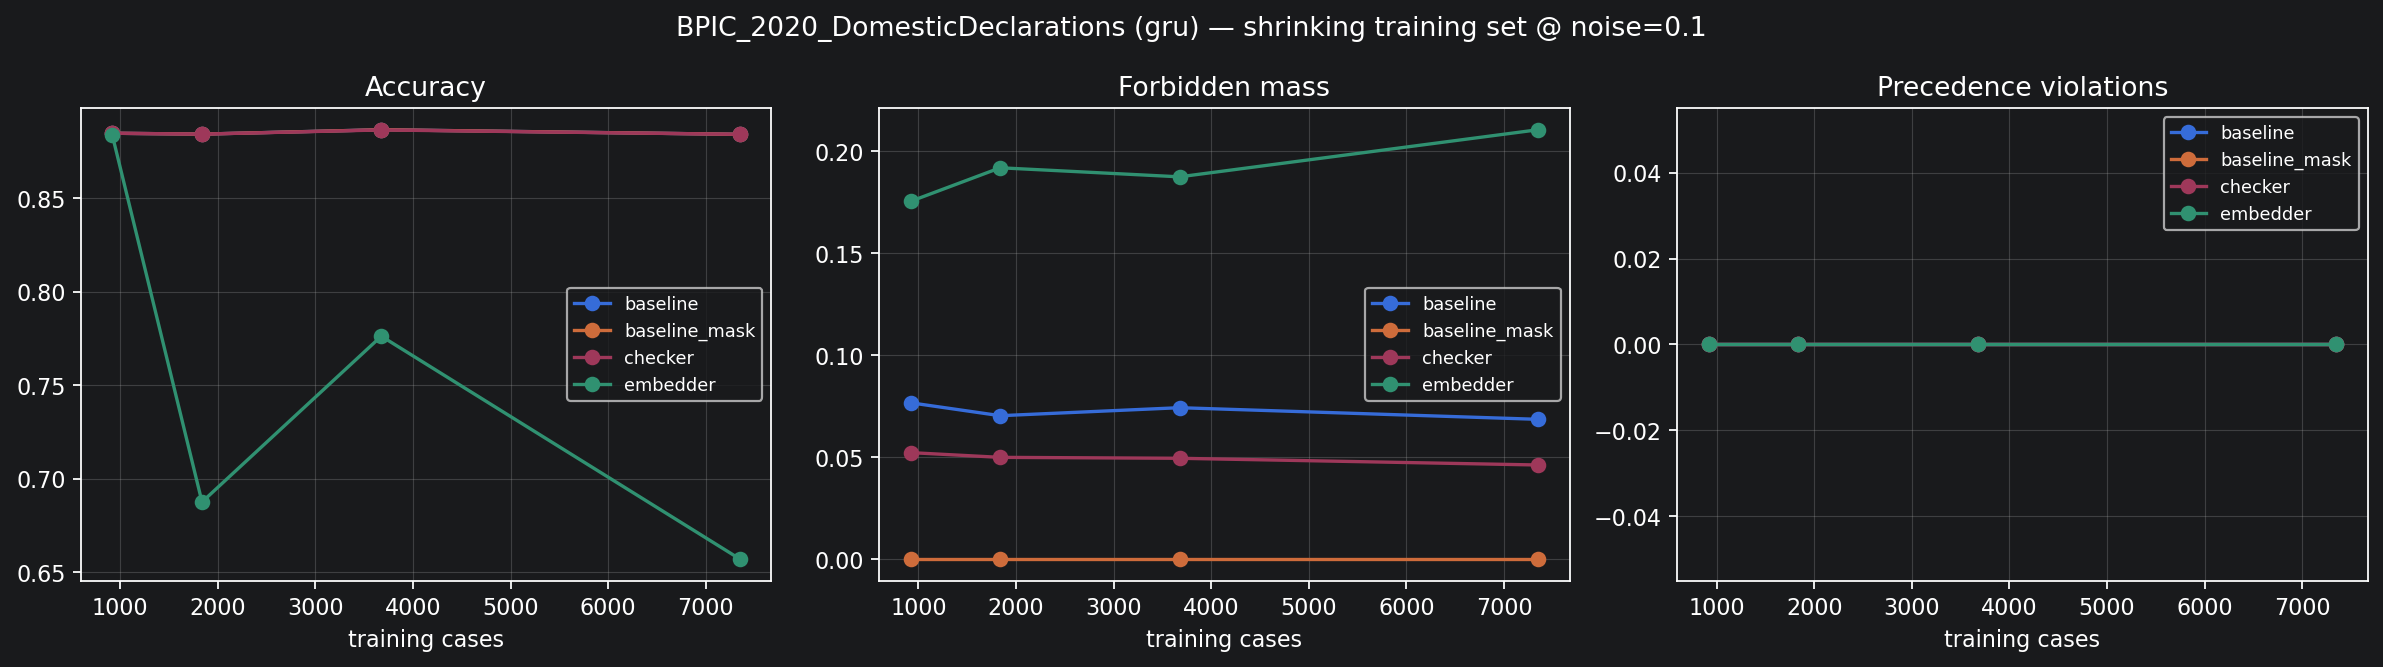

In [13]:
arch = MODELS[0]

full = grid[(grid.train_fraction == 1.0) & (grid.architecture == arch)]
plots.plot_fraction_curves(
    full, ["accuracy", "forbidden_mass", "precedence_violation_rate"],
    OUTPUT_DIR / "noise_curves.png", mode_col="variant",
    x_col="noise_level", x_label="training label noise",
    titles={"accuracy": "Accuracy (higher=better)",
            "forbidden_mass": "Forbidden mass (lower=better)",
            "precedence_violation_rate": "Precedence violations (lower=better)"},
    suptitle=f"{DATASET_NAME} ({arch}) — robustness to label noise @ full data")
display(Image(filename=str(OUTPUT_DIR / "noise_curves.png")))

scarce = grid[(grid.noise_level == 0.1) & (grid.architecture == arch)]
plots.plot_fraction_curves(
    scarce, ["accuracy", "forbidden_mass", "precedence_violation_rate"],
    OUTPUT_DIR / "scarcity_curves.png", mode_col="variant",
    x_col="n_train_cases", x_label="training cases",
    titles={"accuracy": "Accuracy", "forbidden_mass": "Forbidden mass",
            "precedence_violation_rate": "Precedence violations"},
    suptitle=f"{DATASET_NAME} ({arch}) — shrinking training set @ noise=0.1")
display(Image(filename=str(OUTPUT_DIR / "scarcity_curves.png")))

## 9. Conclusions

Read the numbers and curves above for this dataset:

- **Robustness to noise** — how each variant's accuracy degrades as more training
  labels are corrupted, and whether `checker`/`embedder` degrade more gently than
  `baseline` by leaning on the clean symbolic prior.
- **Scarcity** — whether the symbolic prior helps more when training cases are few
  (`1/4`, `1/8`), the regime where a data-only model has least to learn from.
- **Conformance** — `forbidden_mass` / `precedence_violation_rate` show whether
  predictions stay on legal transitions; `baseline+mask` enforces this at
  inference, `checker`/`embedder` push it into the weights during training.

The side-by-side comparison **across the three datasets** (and combined figures)
lives in the dedicated analysis notebook, which loads
`runs/benchmark_corruption.csv`.

In [21]:
combined.reset_index(drop=True).to_csv(RESULTS_CSV, mode='a', header=False, index=False)